In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from src.sgtlib.utils.sgt_utils import sgt_excel_to_dataframe, gen_spider_plot

# Uncomment to install Libraries (if not installed)
#!pip3 install openpyxl

In [2]:
# Read the Excel files and save in one DataFrame
allowed_ext = ".xlsx"
excel_dir_path = "analysis/"

all_sheets = sgt_excel_to_dataframe(excel_dir_path, allowed_ext)

In [3]:
# Filter the relevant materials and parameters
materials = ['ARImGr0S2', 'ARImGr0S3', 'ARImGr0S6', 'ARImGr0S8']
material_names = ['Sample S2', 'Sample S3', 'Sample S6', 'Sample S8']
parameters = ['Nodes', 'Edges', 'AD', 'Diameter', 'GD', 'BC', 'CC', 'EC']

NameError: name 'pivot_avg' is not defined

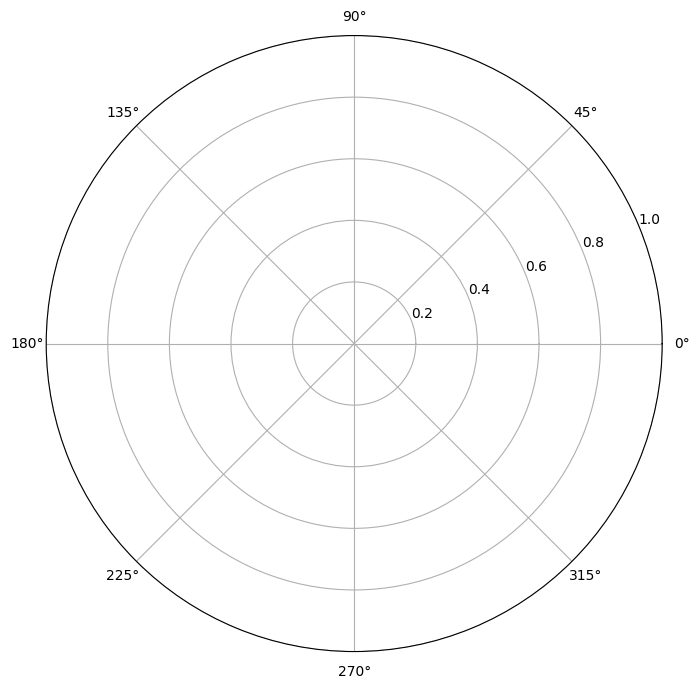

In [8]:
df_sgt = all_sheets['SGT Descriptors']
# df_sgt.columns = df_sgt.iloc[0]
# df_sgt = df_sgt[1:]
# df_sgt = df_sgt.dropna(axis=1)

fig = gen_spider_plot(df_sgt, materials, parameters)
fig.savefig('analysis/plots/spider.png', dpi=300)
plt.show()

C:\Users\owuor\owProjects\StructuralGT\.venv_sgt\Lib\site-packages\scipy\stats\_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


Sample S2 (exponential fit): KS=inf, p-value=0.00
Sample S3 (exponential fit): KS=inf, p-value=0.00
Sample S6 (exponential fit): KS=inf, p-value=0.00
Sample S8 (exponential fit): KS=inf, p-value=0.00


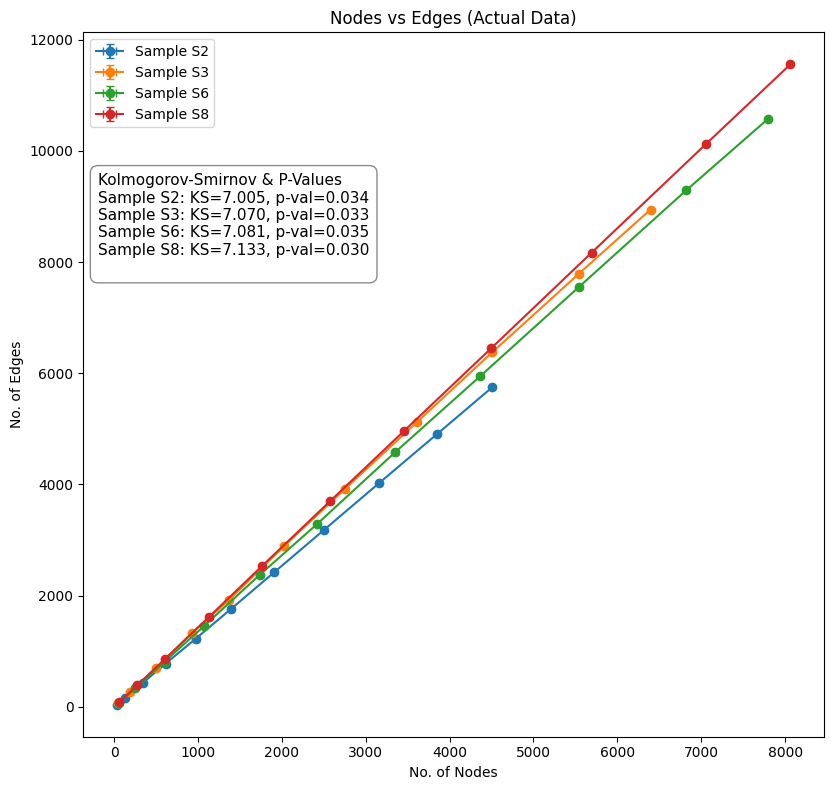

In [4]:
"""
No. Edges
"""
df_edges = all_sheets['Nodes-Edges']


fig = plt.figure(figsize=(16, 8))
ax2 = fig.add_subplot(1, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_edges[df_edges['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.3f}, p-val={res.pvalue:.3f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('No. of Edges')
ax2.set_title('Nodes vs Edges (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.02, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_edges.png', dpi=300)
plt.show()

Sample S2 (exponential fit): KS=inf, p-value=0.00
Sample S3 (exponential fit): KS=inf, p-value=0.00
Sample S6 (exponential fit): KS=inf, p-value=0.00
Sample S8 (exponential fit): KS=inf, p-value=0.00


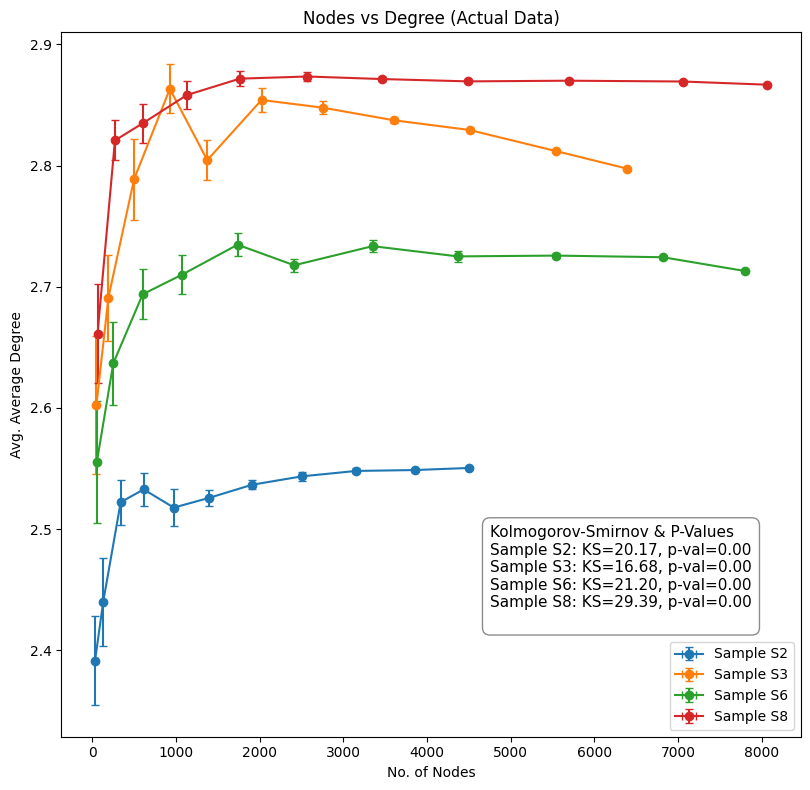

In [5]:
"""
Average Degree
"""
df_deg = all_sheets['Nodes-Degree']


fig = plt.figure(figsize=(16, 8))
ax2 = fig.add_subplot(1, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_deg[df_deg['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.2f}, p-val={res.pvalue:.2f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Average Degree')
ax2.set_title('Nodes vs Degree (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.58, 0.3, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_deg.png', dpi=300)
plt.show()

C:\Users\owuor\owProjects\StructuralGT\.venv_sgt\Lib\site-packages\scipy\stats\_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


Sample S2 (exponential fit): KS=inf, p-value=0.00
Sample S3 (exponential fit): KS=inf, p-value=0.00
Sample S6 (exponential fit): KS=inf, p-value=0.00
Sample S8 (exponential fit): KS=inf, p-value=0.00


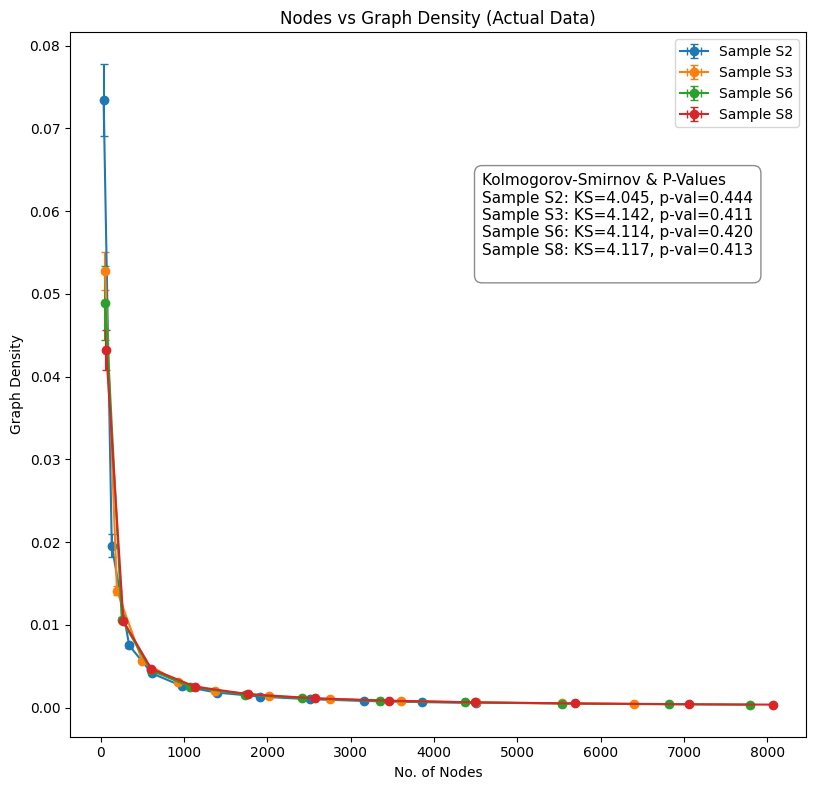

In [6]:
"""
Graph Density
"""
df_dens = all_sheets['Nodes-Density']



fig = plt.figure(figsize=(16, 8))
ax2 = fig.add_subplot(1, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_dens[df_dens['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.3f}, p-val={res.pvalue:.3f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Graph Density')
ax2.set_title('Nodes vs Graph Density (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.56, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_gd.png', dpi=300)
plt.show()

C:\Users\owuor\owProjects\StructuralGT\.venv_sgt\Lib\site-packages\scipy\stats\_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


Sample S2 (exponential fit): KS=inf, p-value=0.00
Sample S3 (exponential fit): KS=inf, p-value=0.00
Sample S6 (exponential fit): KS=inf, p-value=0.00
Sample S8 (exponential fit): KS=inf, p-value=0.00


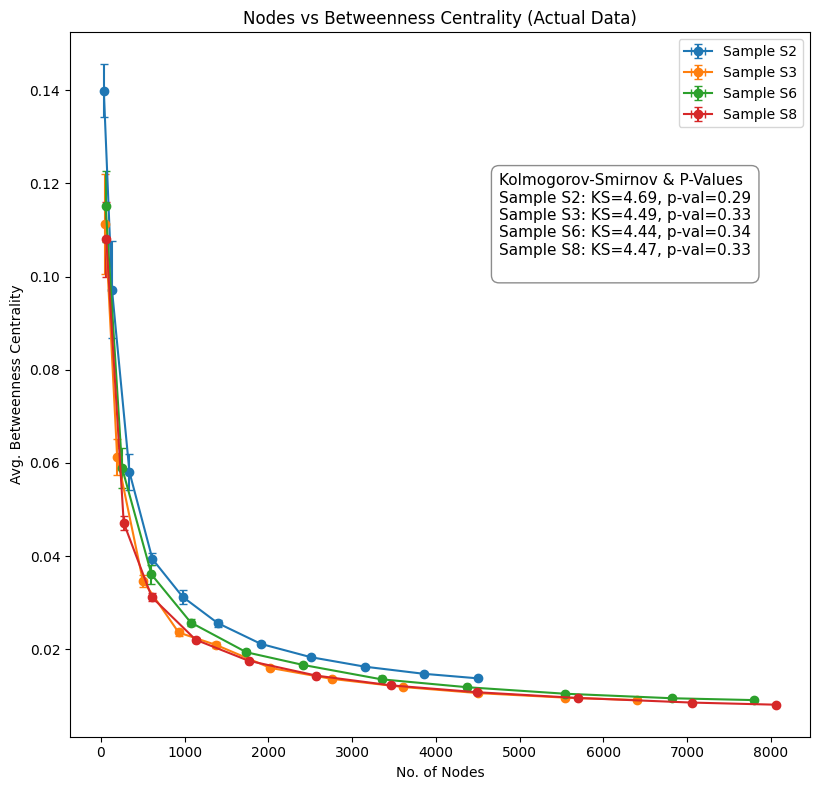

In [7]:
"""
Betweenness
"""
df_bet = all_sheets['Nodes-BC']


fig = plt.figure(figsize=(16, 8))
ax2 = fig.add_subplot(1, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_bet[df_bet['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.2f}, p-val={res.pvalue:.2f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Betweenness Centrality')
ax2.set_title('Nodes vs Betweenness Centrality (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.58, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_bc.png', dpi=300)
plt.show()

C:\Users\owuor\owProjects\StructuralGT\.venv_sgt\Lib\site-packages\scipy\stats\_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


Sample S2 (exponential fit): KS=inf, p-value=0.00
Sample S3 (exponential fit): KS=inf, p-value=0.00
Sample S6 (exponential fit): KS=inf, p-value=0.00
Sample S8 (exponential fit): KS=inf, p-value=0.00


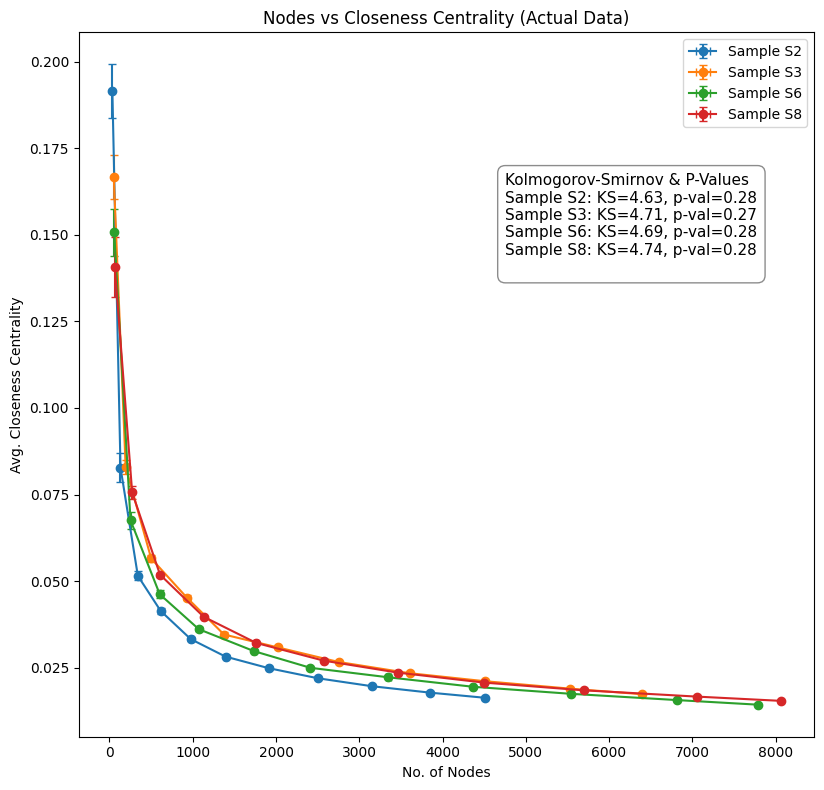

In [8]:
"""
Closeness
"""
df_clo = all_sheets['Nodes-CC']


fig = plt.figure(figsize=(16, 8))
ax2 = fig.add_subplot(1, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_clo[df_clo['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.2f}, p-val={res.pvalue:.2f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Closeness Centrality')
ax2.set_title('Nodes vs Closeness Centrality (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.58, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_cc.png', dpi=300)
plt.show()

C:\Users\owuor\owProjects\StructuralGT\.venv_sgt\Lib\site-packages\scipy\stats\_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


Sample S2 (exponential fit): KS=inf, p-value=0.00
Sample S3 (exponential fit): KS=inf, p-value=0.00
Sample S6 (exponential fit): KS=inf, p-value=0.00
Sample S8 (exponential fit): KS=inf, p-value=0.00


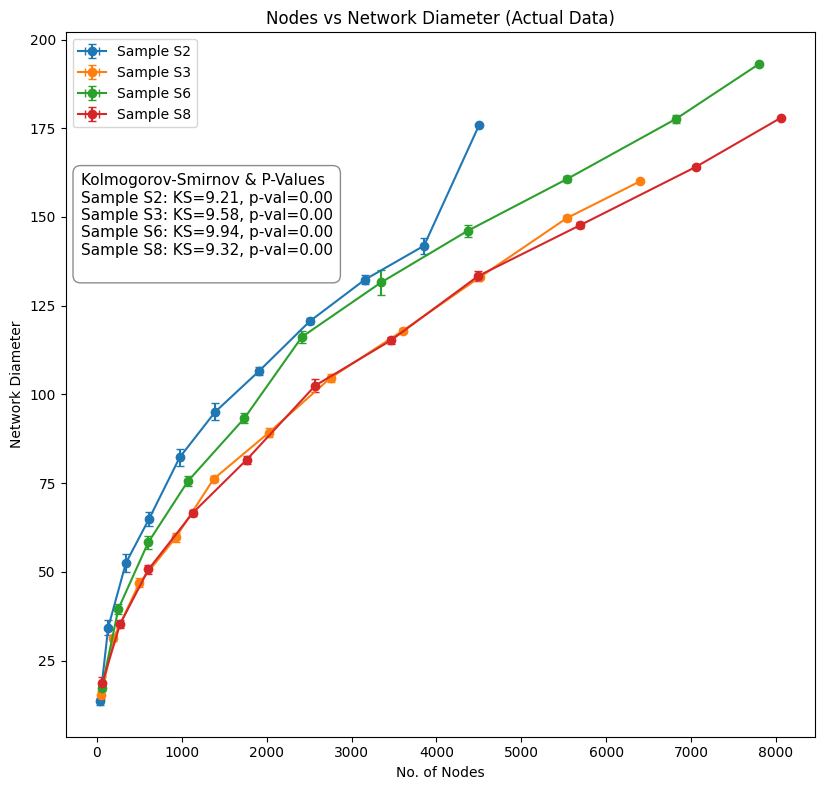

In [9]:
"""
Network Diameter
"""
df_dia = all_sheets['Nodes-Diameter']


fig = plt.figure(figsize=(16, 8))
ax2 = fig.add_subplot(1, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_dia[df_dia['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.2f}, p-val={res.pvalue:.2f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Network Diameter')
ax2.set_title('Nodes vs Network Diameter (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.02, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_nd.png', dpi=300)
plt.show()

C:\Users\owuor\owProjects\StructuralGT\.venv_sgt\Lib\site-packages\scipy\stats\_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


Sample S2 (exponential fit): KS=inf, p-value=0.00
Sample S3 (exponential fit): KS=inf, p-value=0.00
Sample S6 (exponential fit): KS=inf, p-value=0.00
Sample S8 (exponential fit): KS=inf, p-value=0.00


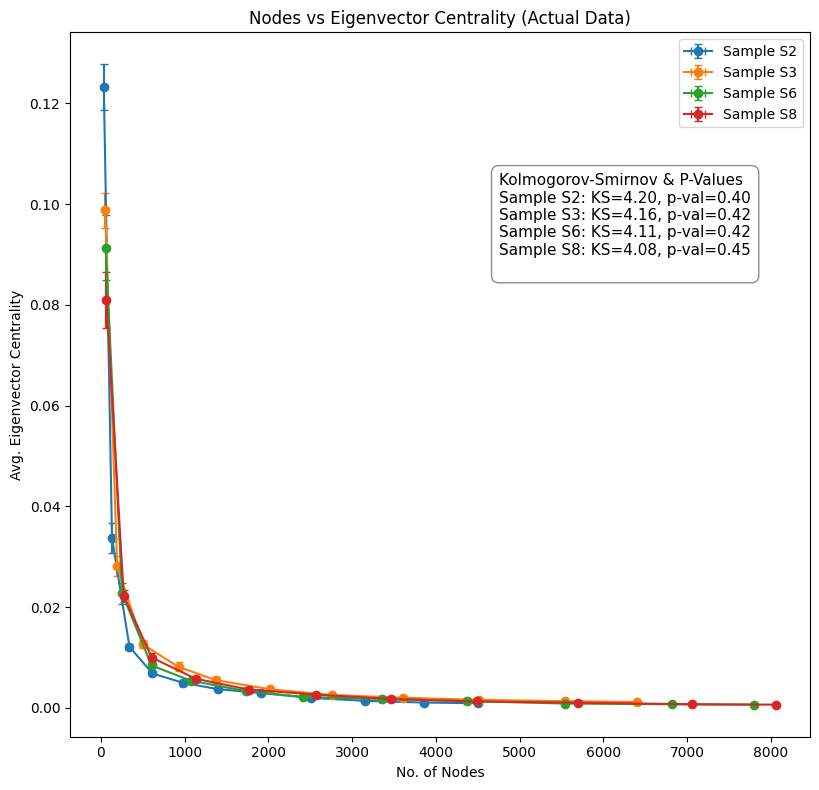

In [10]:
"""
Eigenvector
"""
df_eig = all_sheets['Nodes-EC']




fig = plt.figure(figsize=(16, 8))
ax2 = fig.add_subplot(1, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_eig[df_eig['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.2f}, p-val={res.pvalue:.2f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Eigenvector Centrality')
ax2.set_title('Nodes vs Eigenvector Centrality (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.58, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_ec.png', dpi=300)
plt.show()